In [126]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier

In [127]:
cancer_data = load_breast_cancer()
dir(cancer_data)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [128]:
df = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
df.shape

(569, 30)

In [129]:
df['target'] = cancer_data.target
df['target_names'] = df.target.apply(lambda x: cancer_data.target_names[x])
df.sample(6)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_names
492,18.010,20.56,118.40,1007.0,0.10010,0.12890,0.11700,0.07762,0.2116,0.06077,0.7548,1.2880,5.353,89.74,0.007997,0.02700,0.03737,0.016480,0.02897,0.003996,21.530,26.06,143.40,1426.0,0.1309,0.23270,0.25440,0.14890,0.3251,0.07625,0,malignant
314,8.597,18.60,54.09,221.2,0.10740,0.05847,0.00000,0.00000,0.2163,0.07359,0.3368,2.7770,2.222,17.81,0.020750,0.01403,0.00000,0.000000,0.06146,0.006820,8.952,22.44,56.65,240.1,0.1347,0.07767,0.00000,0.00000,0.3142,0.08116,1,benign
344,11.710,15.45,75.03,420.3,0.11500,0.07281,0.04006,0.03250,0.2009,0.06506,0.3446,0.7395,2.355,24.53,0.009536,0.01097,0.01651,0.011210,0.01953,0.003100,13.060,18.16,84.16,516.4,0.1460,0.11150,0.10870,0.07864,0.2765,0.07806,1,benign
146,11.800,16.58,78.99,432.0,0.10910,0.17000,0.16590,0.07415,0.2678,0.07371,0.3197,1.4260,2.281,24.72,0.005427,0.03633,0.04649,0.018430,0.05628,0.004635,13.740,26.38,91.93,591.7,0.1385,0.40920,0.45040,0.18650,0.5774,0.10300,0,malignant
434,14.860,16.94,94.89,673.7,0.08924,0.07074,0.03346,0.02877,0.1573,0.05703,0.3028,0.6683,1.612,23.92,0.005756,0.01665,0.01461,0.008281,0.01551,0.002168,16.310,20.54,102.30,777.5,0.1218,0.15500,0.12200,0.07971,0.2525,0.06827,1,benign
21,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.02076,0.1815,0.06905,0.2773,0.9768,1.909,15.70,0.009606,0.01432,0.01985,0.014210,0.02027,0.002968,10.230,15.66,65.13,314.9,0.1324,0.11480,0.08867,0.06227,0.2450,0.07773,1,benign


In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [131]:
df.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


In [132]:
X = df.drop(['target', 'target_names'], axis=1)
Y = df['target']

In [133]:
X.head(4)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300


In [134]:
Y.head(4)

,target
0,0
1,0
2,0
3,0


In [135]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)

In [136]:
len(X_train)

455

In [137]:
len(X_test)

114

In [138]:
model = RandomForestClassifier(n_estimators=5)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=5)

In [139]:
model.score(X_test, y_test)

0.9035087719298246

In [140]:
predicted = model.predict(X_test)
predicted

array([1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1,
       0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1,
       1, 0, 1, 0])

In [141]:
cm = confusion_matrix(y_test, predicted)
cm

array([[46,  7],
       [ 4, 57]])

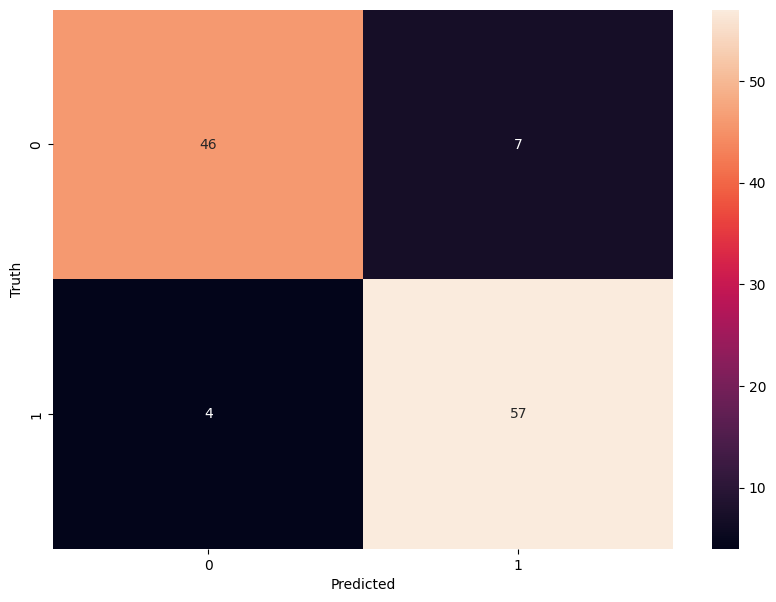

In [142]:
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()

In [145]:
df['prediction'] = model.predict(X)
df['prediction_names'] = df.prediction.apply(lambda x: cancer_data.target_names[x])
df.sample(10)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_names,prediction,prediction_names
382,12.05,22.72,78.75,447.8,0.06935,0.10730,0.07943,0.029780,0.1203,0.06659,0.1194,1.4340,1.7780,9.549,0.005042,0.045600,0.043050,0.016670,0.02470,0.007358,12.57,28.71,87.36,488.4,0.08799,0.3214,0.29120,0.10920,0.2191,0.09349,1,benign,1,benign
516,18.31,20.58,120.80,1052.0,0.10680,0.12480,0.15690,0.094510,0.1860,0.05941,0.5449,0.9225,3.2180,67.360,0.006176,0.018770,0.029130,0.010460,0.01559,0.002725,21.86,26.20,142.20,1493.0,0.14920,0.2536,0.37590,0.15100,0.3074,0.07863,0,malignant,0,malignant
99,14.42,19.77,94.48,642.5,0.09752,0.11410,0.09388,0.058390,0.1879,0.06390,0.2895,1.8510,2.3760,26.850,0.008005,0.028950,0.033210,0.014240,0.01462,0.004452,16.33,30.86,109.50,826.4,0.14310,0.3026,0.31940,0.15650,0.2718,0.09353,0,malignant,0,malignant
509,15.46,23.95,103.80,731.3,0.11830,0.18700,0.20300,0.085200,0.1807,0.07083,0.3331,1.9610,2.9370,32.520,0.009538,0.049400,0.060190,0.020410,0.02105,0.006000,17.11,36.33,117.70,909.4,0.17320,0.4967,0.59110,0.21630,0.3013,0.10670,0,malignant,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.105200,0.2597,0.09744,0.4956,1.1560,3.4450,27.230,0.009110,0.074580,0.056610,0.018670,0.05963,0.009208,14.91,26.50,98.87,567.7,0.20980,0.8663,0.68690,0.25750,0.6638,0.17300,0,malignant,0,malignant
379,11.08,18.83,73.30,361.6,0.12160,0.21540,0.16890,0.063670,0.2196,0.07950,0.2114,1.0270,1.7190,13.990,0.007405,0.045490,0.045880,0.013390,0.01738,0.004435,13.24,32.82,91.76,508.1,0.21840,0.9379,0.84020,0.25240,0.4154,0.14030,0,malignant,0,malignant
403,12.94,16.17,83.18,507.6,0.09879,0.08836,0.03296,0.023900,0.1735,0.06200,0.1458,0.9050,0.9975,11.360,0.002887,0.012850,0.016130,0.007308,0.01870,0.001972,13.86,23.02,89.69,580.9,0.11720,0.1958,0.18100,0.08388,0.3297,0.07834,1,benign,1,benign
40,13.44,21.58,86.18,563.0,0.08162,0.06031,0.03110,0.020310,0.1784,0.05587,0.2385,0.8265,1.5720,20.530,0.003280,0.011020,0.013900,0.006881,0.01380,0.001286,15.93,30.25,102.50,787.9,0.10940,0.2043,0.20850,0.11120,0.2994,0.07146,0,malignant,1,benign
263,15.61,19.38,100.00,758.6,0.07840,0.05616,0.04209,0.028470,0.1547,0.05443,0.2298,0.9988,1.5340,22.180,0.002826,0.009105,0.013110,0.005174,0.01013,0.001345,17.91,31.67,115.90,988.6,0.10840,0.1807,0.22600,0.08568,0.2683,0.06829,0,malignant,0,malignant
442,13.78,15.79,88.37,585.9,0.08817,0.06718,0.01055,0.009937,0.1405,0.05848,0.3563,0.4833,2.2350,29.340,0.006432,0.011560,0.007741,0.005657,0.01227,0.002564,15.27,17.50,97.90,706.6,0.10720,0.1071,0.03517,0.03312,0.1859,0.06810,1,benign,1,benign


In [147]:
df.to_csv('cancer_predicted_data.csv', index=False)